In [3]:
# Implementing cholesky from scratch
import numpy as np
from scipy.linalg import cholesky, solve_triangular

A = np.array([
    [4, 1, 1],
    [1, 5, 2],
    [1, 2, 6]])
L = cholesky(A, lower=True)  # Lower triangular factor
print("Original A:\n", A)
print("L:\n", L)
print("\nL @ L.T:\n", L @ L.T)  # Should equal A
b = np.array([1, 2, 3])
y = solve_triangular(L, b, lower=True)  # Forward solve Ly = b
x = solve_triangular(L.T, y, lower=False)  # Backward solve L.T x = y
print("\nSolution x:", x)

Original A:
 [[4 1 1]
 [1 5 2]
 [1 2 6]]
L:
 [[2.         0.         0.        ]
 [0.5        2.17944947 0.        ]
 [0.5        0.80295507 2.25948294]]

L @ L.T:
 [[4. 1. 1.]
 [1. 5. 2.]
 [1. 2. 6.]]

Solution x: [0.09278351 0.21649485 0.41237113]


#### Example: Gaussian Process Regression using Cholesky

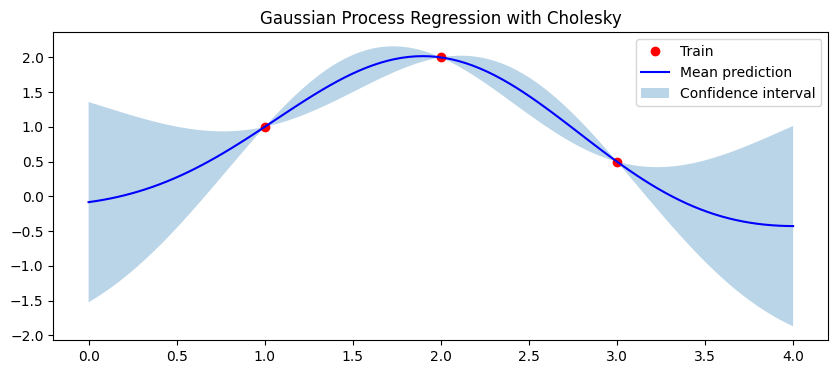

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def rbf_kernel(X1, X2, length_scale=1.0, variance=1.0):
    sqdist = np.sum(X1**2, 1).reshape(-1,1) + np.sum(X2**2, 1) - 2*np.dot(X1, X2.T)
    return variance * np.exp(-0.5 / length_scale**2 * sqdist)

# Training data
X_train = np.array([[1.0], [2.0], [3.0]])
y_train = np.array([1.0, 2.0, 0.5])

# Test points
X_test = np.linspace(0, 4, 100).reshape(-1, 1)

# Kernel computations
K = rbf_kernel(X_train, X_train) + 1e-6 * np.eye(len(X_train))  # Add jitter
K_s = rbf_kernel(X_train, X_test)
K_ss = rbf_kernel(X_test, X_test)

# Cholesky decomposition
L = np.linalg.cholesky(K)

# Solve for alpha: Kα = y → L Lᵗ α = y
# Forward-substitute: L z = y
z = np.linalg.solve(L, y_train)
# Back-substitute: Lᵗ α = z
alpha = np.linalg.solve(L.T, z)

# Predictive mean
mu_s = K_s.T @ alpha

# Predictive variance
v = np.linalg.solve(L, K_s)
cov_s = K_ss - v.T @ v
std_s = np.sqrt(np.diag(cov_s))
plt.figure(figsize=(10, 4))
plt.plot(X_train, y_train, 'ro', label='Train')
plt.plot(X_test, mu_s, 'b-', label='Mean prediction')
plt.fill_between(X_test.flatten(), mu_s - 2*std_s, mu_s + 2*std_s, alpha=0.3, label='Confidence interval')
plt.title("Gaussian Process Regression with Cholesky")
plt.legend()
plt.show()

### What Cholesky does here:
- Efficiently solves Kα=y without inverting K
- Computes predictive variance 
- Enables stable and fast GP predictions and training